In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
!pip install wordcloud
from wordcloud import WordCloud 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
df = pd.read_csv('../../data/processed/tweets_clean.csv')
print('Data loaded:', df.shape)
print(df.head(5))

Data loaded: (12679, 10)
             tweet_id airline_sentiment negativereason         airline  \
0  570301083672813571           neutral            NaN  Virgin America   
1  570301031407624196          negative     Bad Flight  Virgin America   
2  570300817074462722          negative     Can't Tell  Virgin America   
3  570300767074181121          negative     Can't Tell  Virgin America   
4  570300616901320704          positive            NaN  Virgin America   

         name  retweet_count  \
0  yvonnalynn              0   
1    jnardino              0   
2    jnardino              0   
3    jnardino              0   
4  cjmcginnis              0   

                                                text  \
0  @VirginAmerica I didn't today... Must mean I n...   
1  @VirginAmerica it's really aggressive to blast...   
2  @VirginAmerica and it's a really big bad thing...   
3  @VirginAmerica seriously would pay $30 a fligh...   
4  @VirginAmerica yes, nearly every time I fly VX...   



# Exploratory Data Analysis (EDA)

## Chart 1 — Sentiment by Airline
Analysing sentiment breakdown across all 6 airlines 
to identify which airline has the worst customer perception.

In [33]:
df.groupby(['airline', 'airline_sentiment']).size().unstack()

airline_sentiment,negative,neutral,positive
airline,,,
American,1854,338,252
Delta,852,519,422
Southwest,1103,497,450
US Airways,2147,296,204
United,2452,496,373
Virgin America,167,133,124


You have this table stored from your groupby. Now you need to convert each row to percentages.
For each airline, divide each sentiment count by the total tweets for that airline, then multiply by 100.

In [34]:
airline_sentiment = df.groupby(['airline', 'airline_sentiment']).size().unstack()
airline_pct = airline_sentiment.div(airline_sentiment.sum(axis=1), axis=0) * 100
print(airline_pct.round(1))

airline_sentiment  negative  neutral  positive
airline                                       
American               75.9     13.8      10.3
Delta                  47.5     28.9      23.5
Southwest              53.8     24.2      22.0
US Airways             81.1     11.2       7.7
United                 73.8     14.9      11.2
Virgin America         39.4     31.4      29.2


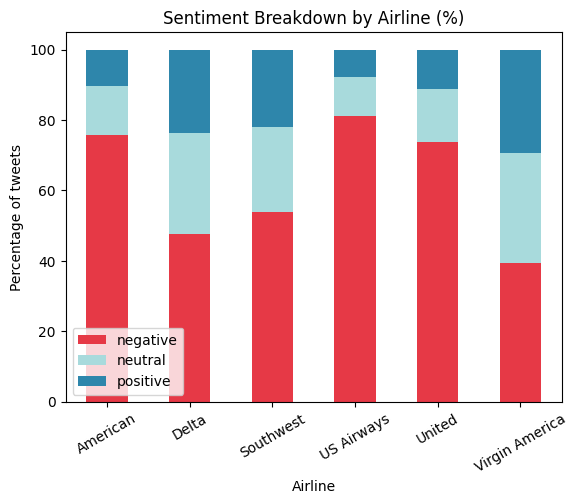

In [35]:
COLORS = {'negative':'#E63946', 'neutral':'#A8DADC', 'positive':'#2E86AB'}

airline_pct[['negative','neutral','positive']].plot(
    kind='bar', stacked=True,
    color=[COLORS['negative'], COLORS['neutral'], COLORS['positive']])
plt.title('Sentiment Breakdown by Airline (%)')
plt.xlabel('Airline')
plt.ylabel('Percentage of tweets')
plt.legend()
plt.xticks(rotation =30)
plt.savefig('../../outputs/01_sentiment_by_airline.png',dpi=150, bbox_inches='tight')
plt.show()

## Key Findings — Sentiment by Airline

- US Airways has the worst sentiment at 81.1% negative
- Virgin America has the best sentiment at 39.4% negative
- Legacy carriers (US Airways, United, American) perform worse 
  than newer airlines (Virgin America, Delta)
- Southwest and Delta show similar sentiment patterns

Chart 2 — Tweet Volume By Airline


Analysing Tweet Volume By Airlines.

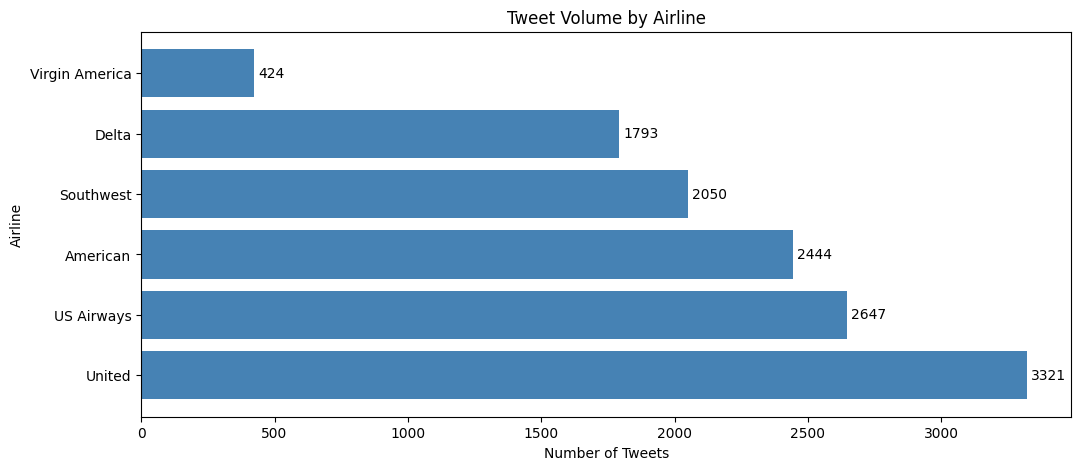

In [36]:
vol = df['airline'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
bar=plt.barh(vol.index, vol.values, color='steelblue')
plt.title('Tweet Volume by Airline')
plt.xlabel('Number of Tweets')
plt.ylabel('Airline')
ax.bar_label(bar, padding=3)
plt.savefig('../../outputs/02_tweet_volume_by_airline.png', 
            dpi=150, bbox_inches='tight')
plt.show()

High volume + High negativity = 
Large number of unhappy customers publicly complaining
= serious brand reputation damage
= potential customer churn at scale

Chart 3 — Top 10 Reasons for Negative Tweets


Analysing Reasons for Tweets.

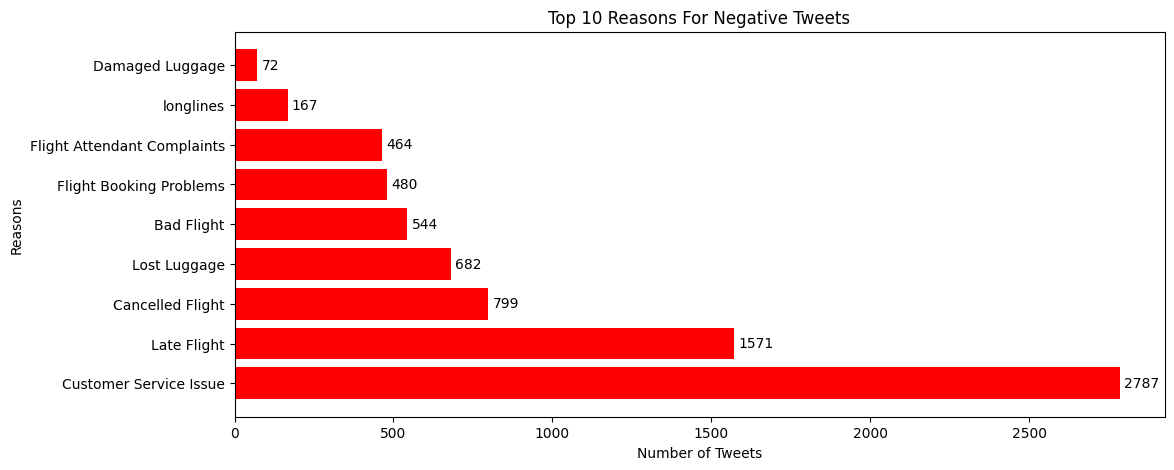

In [37]:
neg_df = df[df['airline_sentiment'] == 'negative']
neg_df = neg_df[neg_df['negativereason'] != "Can't Tell"]
negative_df = neg_df['negativereason'].value_counts().head(10)
fig, ax = plt.subplots(figsize=(12, 5))
bar=plt.barh(negative_df.index, negative_df.values, color='red')
plt.title('Top 10 Reasons For Negative Tweets')
plt.xlabel('Number of Tweets')
plt.ylabel('Reasons')
ax.bar_label(bar, padding=3)
plt.savefig('../../outputs/03_negativity_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

Chart 4 - Most common words in negative tweets

Analyzing most common words using Wordcloud

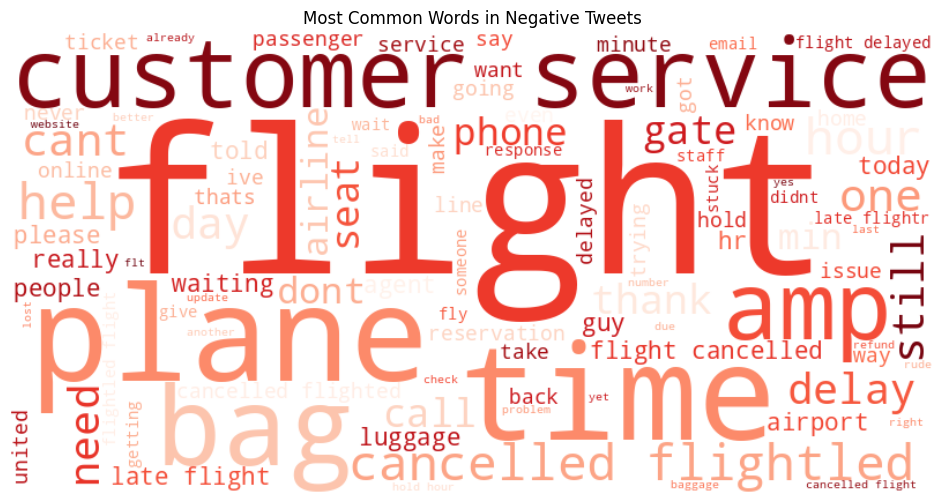

In [38]:
text_data = ' '.join(neg_df['text_clean'].dropna())
wc = WordCloud(width=800,
                height=400, 
                background_color = 'white', 
                colormap = 'Reds',
                max_words=100).generate(text_data)
plt.figure(figsize=(14,6))
plt.imshow(wc,interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets')
plt.savefig('../../outputs/04_wordcloud_negative.png', dpi=150, bbox_inches='tight')

plt.show()

In [39]:
#ensure datetime
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc = True)
print(df['tweet_created'])

0       2015-02-24 19:15:48+00:00
1       2015-02-24 19:15:36+00:00
2       2015-02-24 19:14:45+00:00
3       2015-02-24 19:14:33+00:00
4       2015-02-24 19:13:57+00:00
                   ...           
12674   2015-02-22 20:01:02+00:00
12675   2015-02-22 19:59:46+00:00
12676   2015-02-22 19:59:15+00:00
12677   2015-02-22 19:59:02+00:00
12678   2015-02-22 19:58:51+00:00
Name: tweet_created, Length: 12679, dtype: datetime64[ns, UTC]


Tweet Activity Over Time:


The graph shows the number of tweets posted per day. A noticeable increase in tweet activity occurs around February 22–23, indicating a spike in engagement during this period. To reduce daily noise and highlight the overall trend, a 3-day rolling average was applied. The rolling average confirms a sharp rise followed by a decline, suggesting a short-term event or topic that temporarily increased user activity.

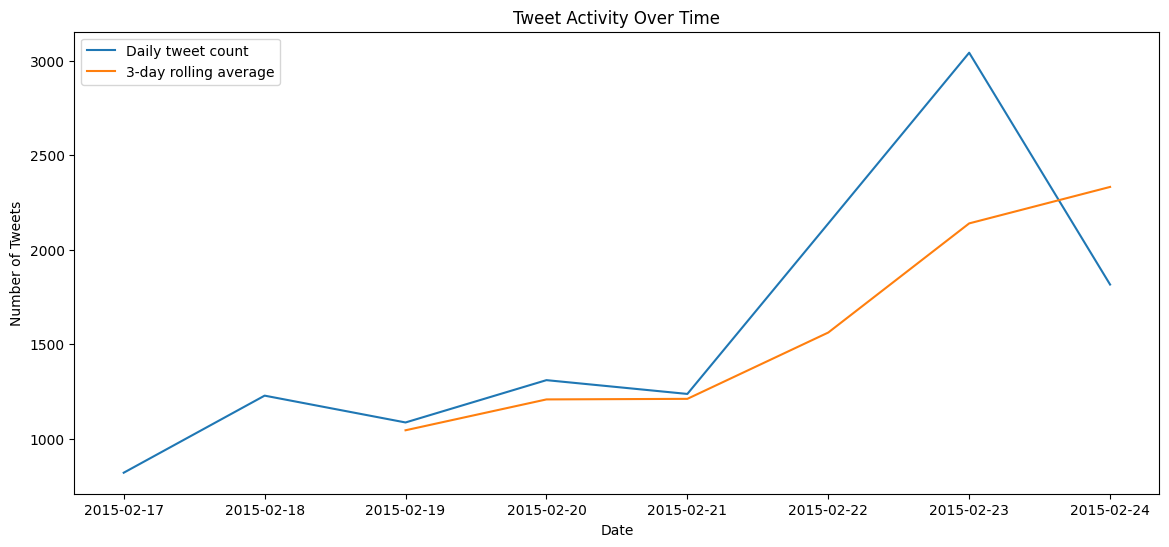

In [46]:
df=df.reset_index()
df=df.set_index('tweet_created')
tweets_per_day = df.resample('D').size()

rolling_avg = tweets_per_day.rolling(3).mean()

plt.figure(figsize=(14,6))
plt.plot(tweets_per_day, label='Daily tweet count')
plt.plot(rolling_avg, label='3-day rolling average')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title('Tweet Activity Over Time')
plt.legend()
plt.show()

In [47]:
tweets_per_day.sort_values(ascending=False).head()

tweet_created
2015-02-23 00:00:00+00:00    3043
2015-02-22 00:00:00+00:00    2139
2015-02-24 00:00:00+00:00    1816
2015-02-20 00:00:00+00:00    1310
2015-02-21 00:00:00+00:00    1237
dtype: int64

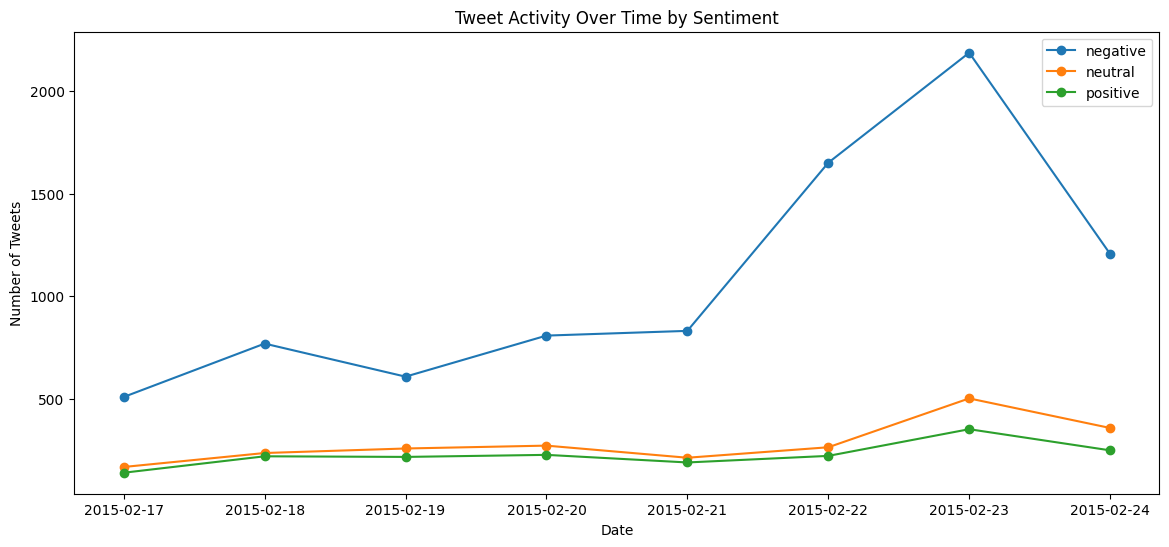

In [50]:
sentiment_daily = (
    df
    .groupby([pd.Grouper(freq='D'), 'airline_sentiment'])
    .size()
    .unstack(fill_value=0)
)
plt.figure(figsize=(14,6))
plt.plot(sentiment_daily, marker='o')
plt.xlabel('Date')
plt.ylabel('Number of Tweets')
plt.title('Tweet Activity Over Time by Sentiment')
plt.legend(sentiment_daily.columns)
plt.show()

This plot separates tweet activity by sentiment over time. The visualization reveals whether spikes in overall activity are driven primarily by positive, negative, or neutral tweets.

Tweet activity shows a significant spike on 23 February 2015, primarily driven by a sharp increase in negative sentiment. While neutral and positive tweets also increased during the spike, their growth was comparatively smaller. This suggests that the event triggering the spike generated strong negative reactions among users rather than balanced or positive discussion.

In [59]:
print(df.columns)

Index(['tweet_id', 'airline_sentiment', 'negativereason', 'airline', 'name',
       'retweet_count', 'text', 'user_timezone', 'text_clean'],
      dtype='object')


In [61]:
df=df.reset_index()
tweets_per_day = df.groupby(df['tweet_created'].dt.date).size()
spike_day = tweets_per_day.idxmax()

print(spike_day)

2015-02-23


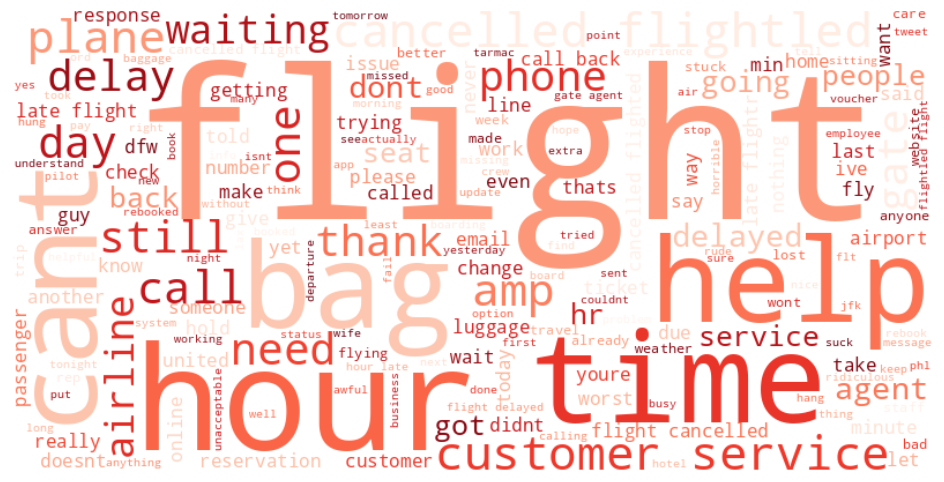

In [63]:
one_day_df = df[df['tweet_created'].dt.date == spike_day]
neg_spike_df = one_day_df[one_day_df['airline_sentiment'] == 'negative']
text_data = ' '.join(neg_spike_df['text_clean'].dropna())

wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='Reds'
).generate(text_data)

plt.figure(figsize=(14,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.show()

Overall Sentiment Distribution

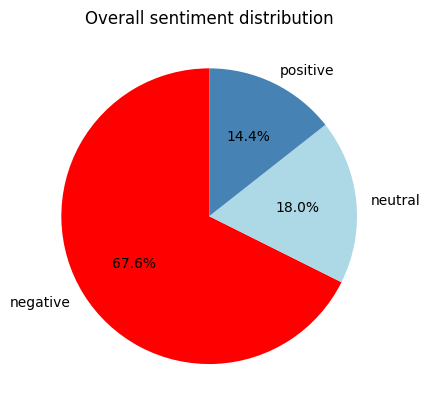

In [64]:
counts = df['airline_sentiment'].value_counts()
colors = ['red', 'lightblue', 'steelblue']
plt.pie(counts,
        labels=counts.index,   
        colors=colors,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Overall sentiment distribution')
plt.savefig('../../outputs/06_sentiment_distribution.png', dpi =150, bbox_inches='tight')
plt.show()

Feature Engineering

In [67]:
df['tweet_length']= df['text'].str.len()
df['word_count'] = df['text_clean'].str.split().str.len()
df['exclamation_count'] = df['text'].str.count('!')
df['has_url'] = df['text'].str.contains('http').astype(int)
df['mention_count'] = df['text'].str.count(r'@\w+')
df['tweet_hour'] = pd.to_datetime(df['tweet_created']).dt.hour
df[['tweet_length','word_count','exclamation_count',
    'has_url','mention_count','tweet_hour']].head(20)

,tweet_length,word_count,exclamation_count,has_url,mention_count,tweet_hour
0,71,8,1,0,1,19
1,126,10,0,0,1,19
2,55,4,0,0,1,19
3,135,11,0,0,1,19
4,85,9,0,0,1,19
5,80,6,0,0,1,18
6,95,8,0,0,1,18
7,83,6,0,0,1,18
8,139,11,2,0,2,18
9,45,4,0,0,1,18


In [66]:
print(df['tweet_length'].describe())
print(df['mention_count'].describe())
print(df['exclamation_count'].describe())

count    12679.000000
mean       110.244026
std         31.080204
min         21.000000
25%         87.000000
50%        120.000000
75%        137.000000
max        229.000000
Name: tweet_length, dtype: float64
count    12679.000000
mean         1.130136
std          0.405172
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: mention_count, dtype: float64
count    12679.000000
mean         0.364145
std          0.935435
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         27.000000
Name: exclamation_count, dtype: float64


# Exploratory Data Analysis (EDA) – Week 1 Summary

##  Dataset Overview
The dataset contains airline-related tweets labeled by sentiment (negative, neutral, positive), airline name, negativity reason, and engagement metrics such as retweet count. 

The primary goal of this EDA was to understand sentiment distribution, airline-level patterns, complaint drivers, and engagement behavior before moving into NLP modeling.

---

## 1. Sentiment Breakdown by Airline

Sentiment proportions vary significantly across airlines.

- Some airlines show extremely high negative sentiment ratios.
- Others have relatively stronger neutral or positive shares.

**Hypothesis:**  
Sentiment distribution is dependent on airline.

H₀: Airline and sentiment are independent.  
H₁: Sentiment distribution differs by airline.

Visual evidence suggests sentiment is not evenly distributed across airlines.

---

## 2. Tweet Volume by Airline

Tweet volume is uneven across airlines.

- United and US Airways show the highest tweet volume.
- Virgin America has the lowest volume.

Higher tweet volume may amplify visible negativity even if proportions are similar.

---

## 3. Top Negative Tweets

The most common negative reasons are:

1. Customer Service Issues
2. Late Flights
3. Cancelled Flights
4. Lost Luggage
5. Bad Flight Experience

Customer service and operational disruptions dominate complaints.

**Hypothesis:**  
Certain complaint types drive higher engagement.

H₀: Negativity reason does not affect engagement.  
H₁: Some complaint categories receive higher engagement.

---

## 4.Most Number Of Negative tweets

Negative tweets appear to receive higher engagement compared to neutral and positive tweets.

**Hypothesis:**  
Negative tweets receive higher average retweet counts.

H₀: Mean retweet count is equal across sentiment classes.  
H₁: Negative tweets have higher mean retweet counts.

Exploratory patterns suggest negative tweets are more amplified.

---

## 5. Tweet Activity Over Time

Tweet activity shows a clear spike during the observed period.

- The spike is primarily driven by negative tweets.
- This suggests a possible external operational event (e.g., widespread delays or service failure).

Negative sentiment drives volume spikes.

---

## 6. Overall Sentiment Distribution

- Negative tweets: **67.6%**
- Neutral tweets: **18.0%**
- Positive tweets: **14.4%**

The dataset is heavily imbalanced toward negative sentiment. This indicates that Twitter is primarily used as a complaint channel for airlines.

**Implication:** Class imbalance must be considered during modeling.

---

## 7. Key Insights from EDA

- The dataset is strongly skewed toward negative sentiment.
- Customer service and flight delays dominate complaint topics.
- Negative tweets drive engagement and volume spikes.
- Sentiment distribution varies across airlines.

---

## 8. Modeling Implications (Transition to Week 2)

Given:
- Class imbalance
- Strong negative skew
- Text-heavy data
- Complex complaint patterns

A transformer-based NLP model (RoBERTa) is appropriate for capturing contextual sentiment patterns.

